## Order Book Imbalance (*for AAPL*)
### The notebook orchastrates: load -> compute -> label -> analyse -> plot

In [1]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lobster_loader import load_lobster_day, add_mid_price
from obi import add_obi_columns
from data_labels import add_forward_returns

# Load Data
msg_path = "data/AAPL_2012-06-21_34200000_57600000_message_10.csv"
book_path = "data/AAPL_2012-06-21_34200000_57600000_orderbook_10.csv"

df = load_lobster_day(msg_path, book_path, n_levels=10)
df = add_mid_price(df)
df = add_obi_columns(df, depths=[1, 5, 10])

df[['time', 'mid_price', 'obi_depth1', 'obi_depth5', 'obi_depth10']].head(10)

# Label
labeled = add_forward_returns(df, horizons=[1, 5, 30, 100])


### Correlation Test

In [2]:
from scipy.stats import spearmanr

obi_cols = ['obi_depth1', 'obi_depth5', 'obi_depth10']
ret_cols = ['fwd_returns_1s', 'fwd_returns_5s', 'fwd_returns_30s', 'fwd_returns_100s']

corr_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)
pval_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)

before = len(df) 
df = add_forward_returns(df, [1, 5, 30, 100])
df_clean = df.dropna(subset=obi_cols+ret_cols) # drop rows with NaN values

after = len(df_clean)
print(f"before: {before}, after: {after}, dropped: {before-after} ({100*(before-after)/before:.1f}%)")

for obi_col in obi_cols:
    for ret_col in ret_cols:
        corr, pval = spearmanr(df_clean[obi_col], df_clean[ret_col])
        corr_table.loc[obi_col, ret_col] = corr
        pval_table.loc[obi_col, ret_col] = pval

print(corr_table)
print(pval_table)

before: 400391, after: 395651, dropped: 4740 (1.2%)
             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1         0.075490        0.041406         0.012346          0.007957
obi_depth5        -0.016049       -0.022851        -0.035984         -0.024578
obi_depth10       -0.038970       -0.024879        -0.034404          0.001175
             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1     0.000000e+00   1.160888e-149     8.082115e-15      5.576611e-07
obi_depth5     5.766972e-24    7.408204e-47    1.696400e-113      6.280774e-54
obi_depth10   8.732582e-133    3.260064e-55    6.558558e-104      4.599047e-01


### Plot

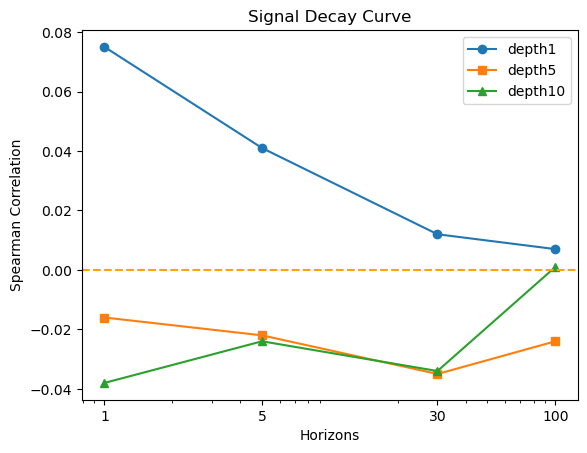

In [3]:
horizons = [1, 5, 30, 100]
corr_depth1 = [0.075, 0.041, 0.012, 0.007]
corr_depth5 = [-0.016, -0.022, -0.035, -0.024]
corr_depth10 = [-0.038, -0.024, -0.034, 0.001]

plt.plot(horizons, corr_depth1, marker='o', label='depth1')
plt.plot(horizons, corr_depth5, marker='s', label='depth5')
plt.plot(horizons, corr_depth10, marker='^', label='depth10')

plt.xscale('log')

plt.axhline(0, color='orange', linestyle='--')
plt.xlabel('Horizons')
plt.ylabel('Spearman Correlation')
plt.title('Signal Decay Curve')
plt.legend()
plt.xticks(horizons, [str(h) for h in horizons])

plt.show()

### Pre-Registered Significance Threshold + Bonferroni Correlation

In [4]:
# number_of_thresholds = 12
new_threshold = 0.05/12
print(new_threshold)

0.004166666666666667


In [5]:
"""
we would call a test significant if p-value < 0.00416
                                    else -> not significant
"""
from scipy.stats import spearmanr

obi_cols = ['obi_depth1', 'obi_depth5', 'obi_depth10']
ret_cols = ['fwd_returns_1s', 'fwd_returns_5s', 'fwd_returns_30s', 'fwd_returns_100s']

corr_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)
pval_table = pd.DataFrame(index=obi_cols, columns=ret_cols, dtype=float)

before = len(df) 
df = add_forward_returns(df, [1, 5, 30, 100])
df_clean = df.dropna(subset=obi_cols+ret_cols) # drop rows with NaN values

after = len(df_clean)
print(f"before: {before}, after: {after}, dropped: {before-after} ({100*(before-after)/before:.1f}%)")

for obi_col in obi_cols:
    for ret_col in ret_cols:
        corr, pval = spearmanr(df_clean[obi_col], df_clean[ret_col])
        corr_table.loc[obi_col, ret_col] = corr
        pval_table.loc[obi_col, ret_col] = pval

print()
print(corr_table)
print()
print(pval_table)
print()
sig_table = pval_table < new_threshold
print(sig_table)

before: 400391, after: 395651, dropped: 4740 (1.2%)

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1         0.075251        0.041381         0.012278          0.008014
obi_depth5        -0.016362       -0.023020        -0.036044         -0.024526
obi_depth10       -0.039227       -0.024787        -0.034426          0.001226

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1     0.000000e+00   1.732362e-149     1.133836e-14      4.631911e-07
obi_depth5     7.607354e-25    1.582318e-47    7.139197e-114      1.044155e-53
obi_depth10   1.605995e-134    8.013374e-55    4.803229e-104      4.404599e-01

             fwd_returns_1s  fwd_returns_5s  fwd_returns_30s  fwd_returns_100s
obi_depth1             True            True             True              True
obi_depth5             True            True             True              True
obi_depth10            True            True             True             Fal